## Main File

__PBJ_Daily_Nurse_Staffing_Q2_2024.csv__

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
import os

# Get the directory of the current file
current_dir = os.path.dirname(os.getcwd())

# Add directory to sys.path
sys.path.insert(0, current_dir)

import quality_check as qc

# Description


The main data file contains information on hours worked grouped by various types of nurses per provider per workdate. This file is specifically for Q2 of 2024.


The primary key combination is composed of PROVNUM and WORKDATE.

# Data Dictionary

| # | Column | Description |
|---|---|---|
| 0 | PROVNUM | Provider number, a unique identifier for each provider. |
| 1 | PROVNAME | Provider name, indicating the name of the healthcare facility. |
| 2 | CITY | The city where the provider is located. |
| 3 | STATE | The state where the provider operates. |
| 4 | COUNTY_NAME | Name of the county where the provider is located. |
| 5 | COUNTY_FIPS | Federal Information Processing Standard (FIPS) code for the county. |
| 6 | CY_Qtr | Calendar Year Quarter, indicating the quarter of the year. |
| 7 | WorkDate | The work date, typically in a numeric or timestamp format. |
| 8 | MDScensus | MDS (Minimum Data Set) census, likely indicating the number of patients. |
| 9 | Hrs_RNDON | Total hours worked by Registered Nurses (RN) on duty. |
| 10 | Hrs_RNDON_emp | Total hours worked by Registered Nurses employed directly by the provider. |
| 11 | Hrs_RNDON_ctr | Total hours worked by contracted Registered Nurses on duty. |
| 12 | Hrs_RNadmin | Total hours worked by Registered Nurse Administrators. |
| 13 | Hrs_RNadmin_emp | Hours worked by RN administrators employed directly by the provider. |
| 14 | Hrs_RNadmin_ctr | Hours worked by contracted RN administrators. |
| 15 | Hrs_RN | Total hours worked by all Registered Nurses. |
| 16 | Hrs_RN_emp | Hours worked by employed Registered Nurses. |
| 17 | Hrs_RN_ctr | Hours worked by contracted Registered Nurses. |
| 18 | Hrs_LPNadmin | Hours worked by Licensed Practical Nurse (LPN) administrators. |
| 19 | Hrs_LPNadmin_emp | Hours worked by employed LPN administrators. |
| 20 | Hrs_LPNadmin_ctr | Hours worked by contracted LPN administrators. |
| 21 | Hrs_LPN | Total hours worked by Licensed Practical Nurses. |
| 22 | Hrs_LPN_emp | Hours worked by employed Licensed Practical Nurses. |
| 23 | Hrs_LPN_ctr | Hours worked by contracted Licensed Practical Nurses. |
| 24 | Hrs_CNA | Total hours worked by Certified Nursing Assistants (CNAs). |
| 25 | Hrs_CNA_emp | Hours worked by employed Certified Nursing Assistants. |
| 26 | Hrs_CNA_ctr | Hours worked by contracted Certified Nursing Assistants. |
| 27 | Hrs_NAtrn | Total hours worked by Nursing Assistants in training. |
| 28 | Hrs_NAtrn_emp | Hours worked by employed Nursing Assistants in training. |
| 29 | Hrs_NAtrn_ctr | Hours worked by contracted Nursing Assistants in training. |
| 30 | Hrs_MedAide | Total hours worked by Medication Aides. |
| 31 | Hrs_MedAide_emp | Hours worked by employed Medication Aides. |
| 32 | Hrs_MedAide_ctr | Hours worked by contracted Medication Aides. |

Failed to load with encoding 'utf-8': 'utf-8' codec can't decode byte 0x92 in position 173163: invalid start byte


/Users/johnathonsmith/DE_Academy/nurse_staffing_analysis_aws_pipeline/data_discovery/quality_check.py:117: DtypeWarning: Columns (0) have mixed types.Specify dtype option on import or set low_memory=False.
  df = load_csv_with_fallback(file_path)


Loaded file successfully with encoding: cp1252

DATASET OVERVIEW
File: PBJ_Daily_Nurse_Staffing_Q2_2024.csv
Rows: 1325324
Columns: 33

COLUMN NAMES AND DATA TYPES
     column_name   dtype
         PROVNUM  object
        PROVNAME  object
            CITY  object
           STATE  object
     COUNTY_NAME  object
     COUNTY_FIPS   int64
          CY_Qtr  object
        WorkDate   int64
       MDScensus   int64
       Hrs_RNDON float64
   Hrs_RNDON_emp float64
   Hrs_RNDON_ctr float64
     Hrs_RNadmin float64
 Hrs_RNadmin_emp float64
 Hrs_RNadmin_ctr float64
          Hrs_RN float64
      Hrs_RN_emp float64
      Hrs_RN_ctr float64
    Hrs_LPNadmin float64
Hrs_LPNadmin_emp float64
Hrs_LPNadmin_ctr float64
         Hrs_LPN float64
     Hrs_LPN_emp float64
     Hrs_LPN_ctr float64
         Hrs_CNA float64
     Hrs_CNA_emp float64
     Hrs_CNA_ctr float64
       Hrs_NAtrn float64
   Hrs_NAtrn_emp float64
   Hrs_NAtrn_ctr float64
     Hrs_MedAide float64
 Hrs_MedAide_emp float64
 Hrs_MedAide


NUMERIC COLUMN SUMMARY
     column_name     count         mean        std        min         25%         50%         75%         max
     COUNTY_FIPS 1325324.0 9.113430e+01  99.128063        1.0       31.00       69.00      117.00      840.00
        WorkDate 1325324.0 2.024052e+07  81.670779 20240401.0 20240423.00 20240516.00 20240608.00 20240630.00
       MDScensus 1325324.0 8.341670e+01  49.041089        0.0       51.00       76.00      104.00      742.00
       Hrs_RNDON 1325324.0 5.195887e+00   4.389664        0.0        0.00        8.00        8.00      103.96
   Hrs_RNDON_emp 1325324.0 5.099312e+00   4.382255        0.0        0.00        8.00        8.00      103.96
   Hrs_RNDON_ctr 1325324.0 9.657448e-02   0.918235        0.0        0.00        0.00        0.00       25.75
     Hrs_RNadmin 1325324.0 1.026275e+01  14.768749        0.0        0.00        7.50       16.00      275.50
 Hrs_RNadmin_emp 1325324.0 1.001164e+01  14.559532        0.0        0.00        7.50       16.0

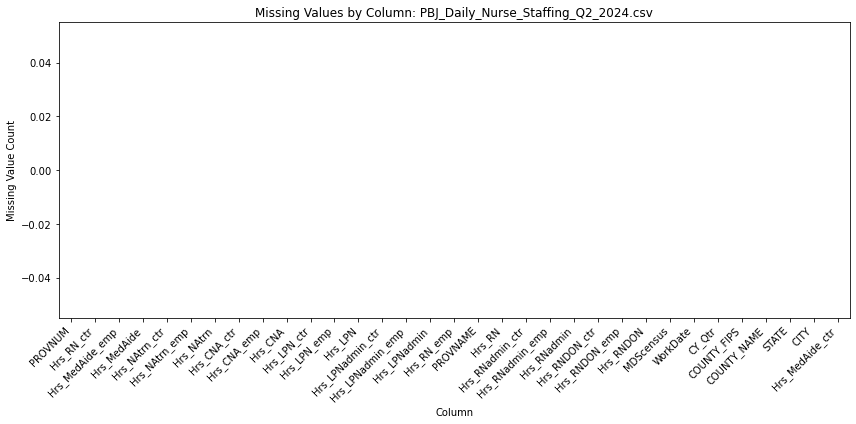

In [2]:
file_path = qc.main_file_path + 'PBJ_Daily_Nurse_Staffing_Q2_2024.csv'
df, profile_df, numeric_summary = qc.analyze_csv_data_quality(file_path)

In [3]:
profile_df

,column_name,dtype,row_count,non_null_count,missing_count,missing_pct,completeness_pct,unique_non_null_values,constant_column_flag,high_missing_flag,possible_type_issue
0,PROVNUM,object,1325324,1325324,0,0.0,100.0,14600,False,False,Possible numeric values stored as text
1,PROVNAME,object,1325324,1325324,0,0.0,100.0,14378,False,False,
2,CITY,object,1325324,1325324,0,0.0,100.0,5086,False,False,
3,STATE,object,1325324,1325324,0,0.0,100.0,52,False,False,
4,COUNTY_NAME,object,1325324,1325324,0,0.0,100.0,1672,False,False,
5,COUNTY_FIPS,int64,1325324,1325324,0,0.0,100.0,287,False,False,
6,CY_Qtr,object,1325324,1325324,0,0.0,100.0,1,True,False,
7,WorkDate,int64,1325324,1325324,0,0.0,100.0,91,False,False,
8,MDScensus,int64,1325324,1325324,0,0.0,100.0,631,False,False,
9,Hrs_RNDON,float64,1325324,1325324,0,0.0,100.0,2377,False,False,


In [4]:
numeric_summary

,column_name,count,mean,std,min,25%,50%,75%,max
0,COUNTY_FIPS,1325324.0,9.113430e+01,99.128063,1.0,31.00,69.00,117.00,840.00
1,WorkDate,1325324.0,2.024052e+07,81.670779,20240401.0,20240423.00,20240516.00,20240608.00,20240630.00
2,MDScensus,1325324.0,8.341670e+01,49.041089,0.0,51.00,76.00,104.00,742.00
3,Hrs_RNDON,1325324.0,5.195887e+00,4.389664,0.0,0.00,8.00,8.00,103.96
4,Hrs_RNDON_emp,1325324.0,5.099312e+00,4.382255,0.0,0.00,8.00,8.00,103.96
5,Hrs_RNDON_ctr,1325324.0,9.657448e-02,0.918235,0.0,0.00,0.00,0.00,25.75
6,Hrs_RNadmin,1325324.0,1.026275e+01,14.768749,0.0,0.00,7.50,16.00,275.50
7,Hrs_RNadmin_emp,1325324.0,1.001164e+01,14.559532,0.0,0.00,7.50,16.00,275.50
8,Hrs_RNadmin_ctr,1325324.0,2.511122e-01,1.845270,0.0,0.00,0.00,0.00,87.25
9,Hrs_RN,1325324.0,3.480192e+01,35.322690,0.0,13.25,25.75,45.25,915.98


In [6]:
qc.check_date_continuity(df, 'WorkDate')

Missing reporting days: 0


DatetimeIndex([], dtype='datetime64[ns]', freq=None)

In [7]:
qc.check_duplicate_keys(df, ['PROVNUM','WorkDate'])

Duplicate key rows: 0


,PROVNUM,PROVNAME,CITY,STATE,COUNTY_NAME,COUNTY_FIPS,CY_Qtr,WorkDate,MDScensus,Hrs_RNDON,...,Hrs_LPN_ctr,Hrs_CNA,Hrs_CNA_emp,Hrs_CNA_ctr,Hrs_NAtrn,Hrs_NAtrn_emp,Hrs_NAtrn_ctr,Hrs_MedAide,Hrs_MedAide_emp,Hrs_MedAide_ctr
